In [22]:
from langgraph.graph import START,StateGraph,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [23]:
load_dotenv()

True

In [24]:
class EmployeeState(TypedDict):
    employee_name:str
    monthly_salary:int
    working_days:int
    completed_projects:int
    yearly_salary:int
    bonus_amount:int
    project_status:str
    summary:str
    


In [25]:
def calculate_bonus(state:EmployeeState) -> EmployeeState:
    bonus=state['monthly_salary']*2
    state['bonus_amount']=bonus
    return {
        "bonus_amount": bonus
    }
    
    
    

In [26]:
def calculate_yearly_salary(state:EmployeeState) -> EmployeeState:
    yearly_sal=state['monthly_salary']*12
    state['yearly_salary']=yearly_sal
    return {
          'yearly_salary':yearly_sal
    }

    

In [29]:
def project_evalutioon(state:EmployeeState) -> EmployeeState:
    if state['completed_projects']>=5:
        status='Excellent'
    else:
        status="Average"
    state['project_status']=status
    return {
        'project_status':status
    }
    
    
    

In [30]:
def project_summary(state:EmployeeState) -> EmployeeState:
    summaery_text=f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and bouns {state['bonus_amount']} and project status as {state['project_status']}"
    state['summary']=summaery_text
    return {
        'summary':summaery_text
        
    }
    

In [31]:
graph=StateGraph(EmployeeState)

graph.add_node('calculate_bonus',calculate_bonus)
graph.add_node('calculate_yearly_salary',calculate_yearly_salary)
graph.add_node('project_evalutioon',project_evalutioon)
graph.add_node('project_summary',project_summary)
graph.add_edge(START,'calculate_bonus')
graph.add_edge(START,'calculate_yearly_salary')
graph.add_edge(START,'project_evalutioon')

graph.add_edge('calculate_bonus','project_summary')
graph.add_edge('calculate_yearly_salary','project_summary')
graph.add_edge('project_evalutioon','project_summary')

graph.add_edge('project_summary',END)


In [32]:
workflow=graph.compile()

In [33]:
employees_data={'employee_name':'Ashok Boppana','monthly_salary':66000,'completed_projects':10,'working_days':200}
response=workflow.invoke(employees_data)

In [34]:
response

{'employee_name': 'Ashok Boppana',
 'monthly_salary': 66000,
 'working_days': 200,
 'completed_projects': 10,
 'yearly_salary': 792000,
 'bonus_amount': 132000,
 'project_status': 'Excellent',
 'summary': 'Employee Ashok Boppana has a yearly salary of 792000 and bouns 132000 and project status as Excellent'}

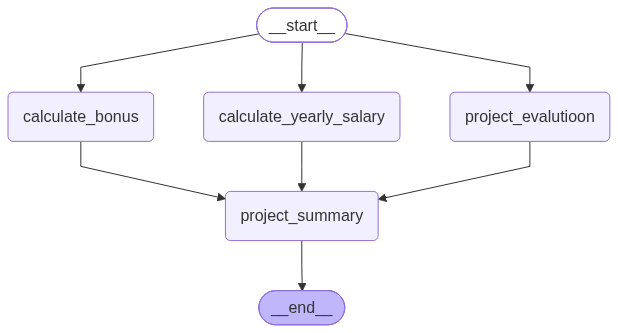

In [37]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())